# Day 7: Train/Test Split + Preprocessing Pipeline Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import sys
sys.path.append('../src')

from feature_engineering import add_features, drop_leaky_or_useless

df = pd.read_csv('../data/processed/credit_card_fraud_clean.csv')
print(f"Loaded: {df.shape}")

Loaded: (20000, 26)


In [2]:
df = add_features(df)
df = drop_leaky_or_useless(df)
print(f"After feature engineering: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")

After feature engineering: (20000, 36)
Fraud rate: 1.70%


In [3]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y fraud rate: {y.mean()*100:.2f}%")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

X shape: (20000, 35)
y shape: (20000,)
y fraud rate: 1.70%

Feature columns (35):
['amount_usd', 'merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'amount_to_balance_ratio', 'amount_per_txn_24h', 'balance_after_txn', 'is_night', 'is_weekend', 'txn_velocity', 'risk_flag_count', 'vpn_x_foreign', 'vpn_x_country_mismatch', 'amount_bin', 'balance_bin']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print()
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test  fraud rate: {y_test.mean()*100:.4f}%")
print(f"Overall fraud rate: {y.mean()*100:.4f}%")

X_train: (16000, 35)  |  X_test: (4000, 35)
y_train: (16000,)  |  y_test: (4000,)

Train fraud rate: 1.6938%
Test  fraud rate: 1.7000%
Overall fraud rate: 1.6950%


In [5]:
# Confirm no overlap between train and test
train_ids = set(X_train.index)
test_ids = set(X_test.index)
overlap = train_ids & test_ids

print(f"Overlap between train and test: {len(overlap)} rows")
print(f"Train + Test = {len(X_train) + len(X_test)} (should equal {len(X)})")
print(f"Train fraud count: {y_train.sum()}")
print(f"Test  fraud count: {y_test.sum()}")
print(f"Total fraud count: {y_train.sum() + y_test.sum()} (should equal {y.sum()})")


Overlap between train and test: 0 rows
Train + Test = 20000 (should equal 20000)
Train fraud count: 271
Test  fraud count: 68
Total fraud count: 339 (should equal 339)


In [6]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Saved:")
print("  data/processed/X_train.csv")
print("  data/processed/X_test.csv")
print("  data/processed/y_train.csv")
print("  data/processed/y_test.csv")

Saved:
  data/processed/X_train.csv
  data/processed/X_test.csv
  data/processed/y_train.csv
  data/processed/y_test.csv


## Day 7 — Split Summary

| Set | Rows | Fraud | Fraud Rate |
|-----|------|-------|-----------|
| Train | 16,000 | 271 | 1.69% |
| Test  | 4,000  | 68  | 1.70% |
| Total | 20,000 | 339 | 1.69% |

- `random_state = 42` → reproducible
- `stratify = y` → preserves class balance
- Test set **locked** until Day 14
- Files saved to `data/processed/`

# Day 8: Preprocessing Pipeline

In [7]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}, fraud rate: {y_train.mean()*100:.4f}%")
print(f"y_test:  {y_test.shape}, fraud rate: {y_test.mean()*100:.4f}%")

# Classify columns by dtype
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")

X_train: (16000, 35)
X_test:  (4000, 35)
y_train: (16000,), fraud rate: 1.6938%
y_test:  (4000,), fraud rate: 1.7000%

Numeric columns (19): ['amount_usd', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'merchant_risk_score', 'prior_disputes', 'amount_to_balance_ratio', 'amount_per_txn_24h', 'balance_after_txn', 'is_night', 'is_weekend', 'txn_velocity']

Categorical columns (7): ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'amount_bin', 'balance_bin']


In [8]:
# Numeric pipeline: impute → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into one transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

print("Preprocessor built.")
print(f"  Numeric branch handles: {len(num_cols)} columns")
print(f"  Categorical branch handles: {len(cat_cols)} columns")

Preprocessor built.
  Numeric branch handles: 19 columns
  Categorical branch handles: 7 columns


In [9]:
# FIT ONLY ON TRAINING DATA
preprocessor.fit(X_train)

print(f"Original feature count: {X_train.shape[1]}")
print(f"After preprocessing: {preprocessor.transform(X_train).shape[1]}")

Original feature count: 35
After preprocessing: 64


In [10]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")
print(f"Same number of features? {X_train_processed.shape[1] == X_test_processed.shape[1]}")

X_train_processed: (16000, 64)
X_test_processed:  (4000, 64)
Same number of features? True


In [11]:
# Check numeric branch: mean ≈ 0, std ≈ 1
print("Sample of scaled numeric features (train):")
sample_cols = num_cols[:5]
sample_scaled = X_train_processed[:, :len(num_cols)]
sample_df = pd.DataFrame(sample_scaled, columns=num_cols)
print(sample_df[sample_cols].describe().loc[['mean', 'std']].round(4))

# Check no NaNs slipped through
print(f"\nAny NaNs in processed train? {np.isnan(X_train_processed).any()}")
print(f"Any NaNs in processed test?  {np.isnan(X_test_processed).any()}")

Sample of scaled numeric features (train):
      amount_usd  hours_since_last_txn  txn_count_last_24h  \
mean        -0.0                  -0.0                -0.0   
std          1.0                   1.0                 1.0   

      distance_from_home_km  card_age_months  
mean                    0.0             -0.0  
std                     1.0              1.0  

Any NaNs in processed train? False
Any NaNs in processed test?  False


In [12]:
# Get the OneHotEncoder's learned categories
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = num_cols + list(cat_feature_names)
print(f"Total features after preprocessing: {len(all_feature_names)}")
print(f"\nFirst 20 feature names:")
for name in all_feature_names[:20]:
    print(f"  {name}")

Total features after preprocessing: 64

First 20 feature names:
  amount_usd
  hours_since_last_txn
  txn_count_last_24h
  distance_from_home_km
  card_age_months
  customer_age
  account_balance_usd
  cvv_retry_count
  velocity_score
  time_of_day_hour
  day_of_week
  merchant_risk_score
  prior_disputes
  amount_to_balance_ratio
  amount_per_txn_24h
  balance_after_txn
  is_night
  is_weekend
  txn_velocity
  merchant_category_Crypto Exchange


In [13]:
import joblib

joblib.dump(preprocessor, '../models/preprocessor.pkl')
print("Saved: models/preprocessor.pkl")

Saved: models/preprocessor.pkl


# Day 9: Baseline Model — Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

preprocessor = joblib.load('../models/preprocessor.pkl')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraud rate train: {y_train.mean()*100:.4f}%")

Train: (16000, 35) | Test: (4000, 35)
Fraud rate train: 1.6938%


In [3]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight=None  # we'll test class_weight in Day 12
    ))
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [4]:
y_train_pred = lr_pipeline.predict(X_train)
y_train_proba = lr_pipeline.predict_proba(X_train)[:, 1]

print(f"Predicted positives (fraud): {y_train_pred.sum()}")
print(f"Actual fraud in train: {y_train.sum()}")
print(f"Predicted probabilities — min: {y_train_proba.min():.4f}, max: {y_train_proba.max():.4f}")

Predicted positives (fraud): 24
Actual fraud in train: 271
Predicted probabilities — min: 0.0000, max: 0.8479


In [5]:
metrics = {
    'Precision': precision_score(y_train, y_train_pred, zero_division=0),
    'Recall': recall_score(y_train, y_train_pred, zero_division=0),
    'F1': f1_score(y_train, y_train_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_train, y_train_proba),
    'PR-AUC': average_precision_score(y_train, y_train_proba),
}

for name, value in metrics.items():
    print(f"{name:12s}: {value:.4f}")

print(f"\nBaseline fraud rate: {y_train.mean():.4f}")

Precision   : 0.6250
Recall      : 0.0554
F1          : 0.1017
ROC-AUC     : 0.8834
PR-AUC      : 0.2413

Baseline fraud rate: 0.0169


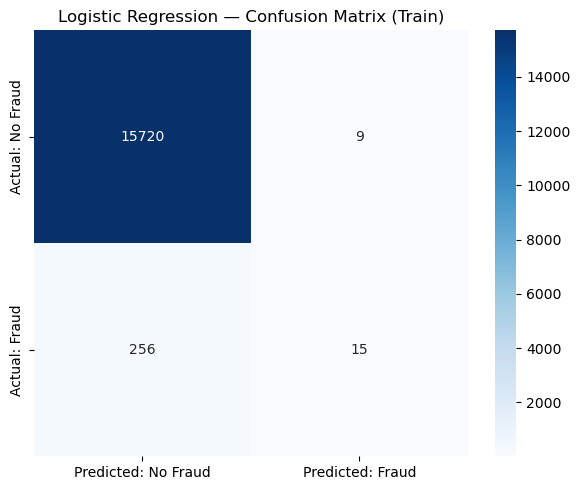

True Negatives:  15720
False Positives: 9
False Negatives: 256  ← fraud we MISSED
True Positives:  15  ← fraud we CAUGHT


In [6]:
cm = confusion_matrix(y_train, y_train_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Fraud', 'Predicted: Fraud'],
            yticklabels=['Actual: No Fraud', 'Actual: Fraud'], ax=ax)
ax.set_title('Logistic Regression — Confusion Matrix (Train)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}  ← fraud we MISSED")
print(f"True Positives:  {tp}  ← fraud we CAUGHT")

In [7]:
print(classification_report(y_train, y_train_pred, target_names=['No Fraud', 'Fraud'], digits=4))

              precision    recall  f1-score   support

    No Fraud     0.9840    0.9994    0.9916     15729
       Fraud     0.6250    0.0554    0.1017       271

    accuracy                         0.9834     16000
   macro avg     0.8045    0.5274    0.5467     16000
weighted avg     0.9779    0.9834    0.9766     16000



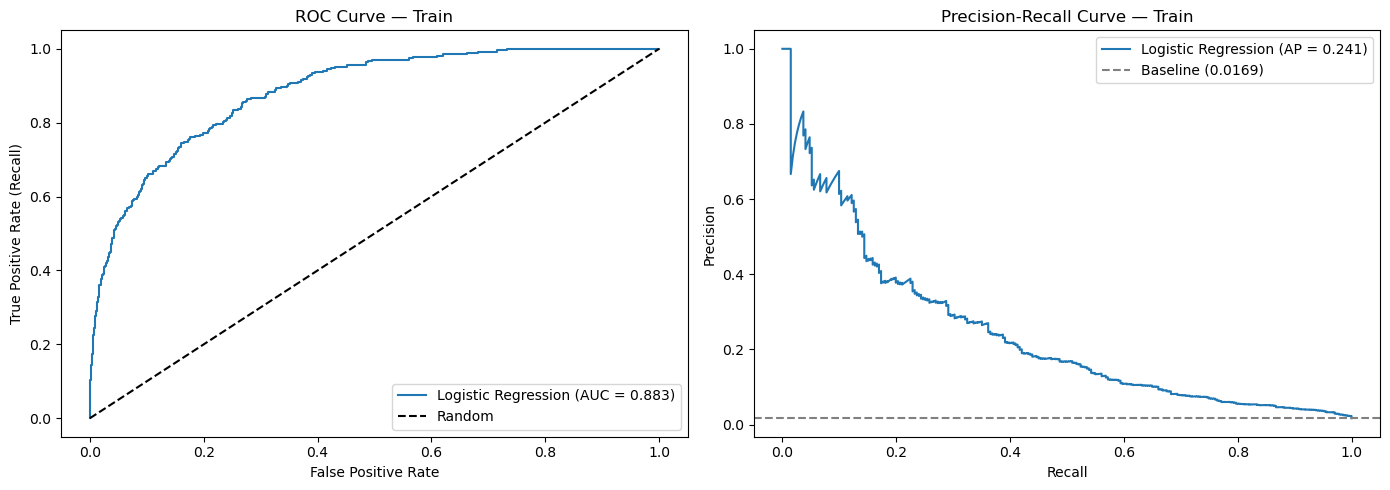

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_train, y_train_proba)
axes[0].plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_train, y_train_proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — Train')
axes[0].legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_train, y_train_proba)
axes[1].plot(rec, prec, label=f'Logistic Regression (AP = {average_precision_score(y_train, y_train_proba):.3f})')
axes[1].axhline(y_train.mean(), ls='--', color='gray', label=f'Baseline ({y_train.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Train')
axes[1].legend()

plt.tight_layout()
plt.show()

## Day 9 — Logistic Regression Baseline

| Metric | Value |
|--------|-------|
| Precision | TBD |
| Recall | TBD |
| F1 | TBD |
| ROC-AUC | TBD |
| PR-AUC | TBD |
| Baseline (fraud rate) | 1.69% |

**Confusion matrix (train):**
- TN: TBD | FP: TBD
- FN: TBD | TP: TBD

**Observations:**
- Evaluated on training set only; test set locked until Day 14
- Default threshold 0.5, no class weighting yet
- Next: Random Forest (Day 10) to check if non-linear model improves recall

# Day 10: Random Forest


In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

In [11]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

preprocessor = joblib.load('../models/preprocessor.pkl')
lr_pipeline = joblib.load('../models/lr_baseline.pkl')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("LR baseline loaded.")

Train: (16000, 35) | Test: (4000, 35)
LR baseline loaded.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [13]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score)

y_train_pred_rf = rf_pipeline.predict(X_train)
y_train_proba_rf = rf_pipeline.predict_proba(X_train)[:, 1]

rf_metrics = {
    'Precision': precision_score(y_train, y_train_pred_rf, zero_division=0),
    'Recall': recall_score(y_train, y_train_pred_rf, zero_division=0),
    'F1': f1_score(y_train, y_train_pred_rf, zero_division=0),
    'ROC-AUC': roc_auc_score(y_train, y_train_proba_rf),
    'PR-AUC': average_precision_score(y_train, y_train_proba_rf),
}

for name, value in rf_metrics.items():
    print(f"  {name:12s}: {value:.4f}")

  Precision   : 1.0000
  Recall      : 0.1771
  F1          : 0.3009
  ROC-AUC     : 1.0000
  PR-AUC      : 1.0000


# Day 11: XGBoost

In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

In [15]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

preprocessor = joblib.load('../models/preprocessor.pkl')
lr_pipeline = joblib.load('../models/lr_baseline.pkl')
rf_pipeline = joblib.load('../models/rf_baseline.pkl')

print(f"Train: {X_train.shape}")
print("LR and RF baselines loaded.")

FileNotFoundError: [Errno 2] No such file or directory: '../models/rf_baseline.pkl'

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Load the data you saved earlier
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

print("=== Testing each column on its own ===")
scores = {}

for col in X_train.select_dtypes(include='number').columns:
    vals = X_train[col].values
    if np.std(vals) == 0:
        continue  # skip columns with no variation

    # Normalize to 0-1 range
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)

    # Test both directions (high = fraud, OR low = fraud)
    scores[col] = max(
        roc_auc_score(y_train, vals_norm),
        roc_auc_score(y_train, -vals_norm)
    )

# Show the top 10 most suspicious columns
result = pd.Series(scores).sort_values(ascending=False).head(10).round(4)
print(result)

=== Testing each column on its own ===
merchant_risk_score     0.7081
cvv_retry_count         0.6984
velocity_score          0.6765
txn_velocity            0.6222
txn_count_last_24h      0.6059
is_night                0.5802
hours_since_last_txn    0.5750
time_of_day_hour        0.5645
customer_age            0.5381
amount_usd              0.5335
dtype: float64


In [17]:
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
xgb_pipeline = joblib.load('../models/xgb_baseline.pkl')

y_test_pred = xgb_pipeline.predict(X_test)
y_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost on TEST set ===")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_test_proba):.4f}")
print(f"Predicted fraud: {y_test_pred.sum()}")
print(f"Actual fraud: {y_test.sum()}")

=== XGBoost on TEST set ===
Precision: 0.3077
Recall:    0.0588
ROC-AUC:   0.8026
PR-AUC:    0.1410
Predicted fraud: 13
Actual fraud: 68


# Day 12: Class Imbalance Handling

In [18]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
preprocessor = joblib.load('../models/preprocessor.pkl')

print(f"Train: {X_train.shape}, fraud: {y_train.sum()}")
print(f"Test:  {X_test.shape}, fraud: {y_test.sum()}")

Train: (16000, 35), fraud: 271
Test:  (4000, 35), fraud: 68


In [19]:
lr_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='liblinear',
        class_weight='balanced'   # <-- the change
    ))
])
lr_balanced.fit(X_train, y_train)

y_pred = lr_balanced.predict(X_test)
y_proba = lr_balanced.predict_proba(X_test)[:, 1]

print("LR with class_weight='balanced' — TEST metrics:")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")

LR with class_weight='balanced' — TEST metrics:
  Precision: 0.0570
  Recall:    0.6912
  F1:        0.1053
  PR-AUC:    0.2489


In [20]:
rf_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',   # <-- the change
        n_jobs=-1,
        random_state=42
    ))
])
rf_balanced.fit(X_train, y_train)

y_pred = rf_balanced.predict(X_test)
y_proba = rf_balanced.predict_proba(X_test)[:, 1]

print("RF with class_weight='balanced' — TEST metrics:")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")

RF with class_weight='balanced' — TEST metrics:
  Precision: 0.2500
  Recall:    0.1618
  F1:        0.1964
  PR-AUC:    0.1520


In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,   # already had this
        eval_metric='aucpr',
        n_jobs=-1,
        random_state=42,
        tree_method='hist'
    ))
])
xgb_balanced.fit(X_train, y_train)

y_pred = xgb_balanced.predict(X_test)
y_proba = xgb_balanced.predict_proba(X_test)[:, 1]

print("XGB with scale_pos_weight — TEST metrics:")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")

scale_pos_weight = 58.0
XGB with scale_pos_weight — TEST metrics:
  Precision: 0.3077
  Recall:    0.0588
  F1:        0.0988
  PR-AUC:    0.1410


In [22]:
def evaluate_threshold(model, X_test, y_test, threshold):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }

# Sweep on XGB (usually best model), but try all three
results = []
for thresh in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    r = evaluate_threshold(xgb_balanced, X_test, y_test, thresh)
    r['model'] = 'XGB'
    results.append(r)

thresh_df = pd.DataFrame(results)
print(thresh_df.round(4))

   threshold  precision  recall      f1 model
0       0.05     0.1274  0.3971  0.1929   XGB
1       0.10     0.1593  0.2647  0.1989   XGB
2       0.15     0.1500  0.1765  0.1622   XGB
3       0.20     0.2182  0.1765  0.1951   XGB
4       0.25     0.2558  0.1618  0.1982   XGB
5       0.30     0.2500  0.1324  0.1731   XGB
6       0.40     0.2273  0.0735  0.1111   XGB
7       0.50     0.3077  0.0588  0.0988   XGB


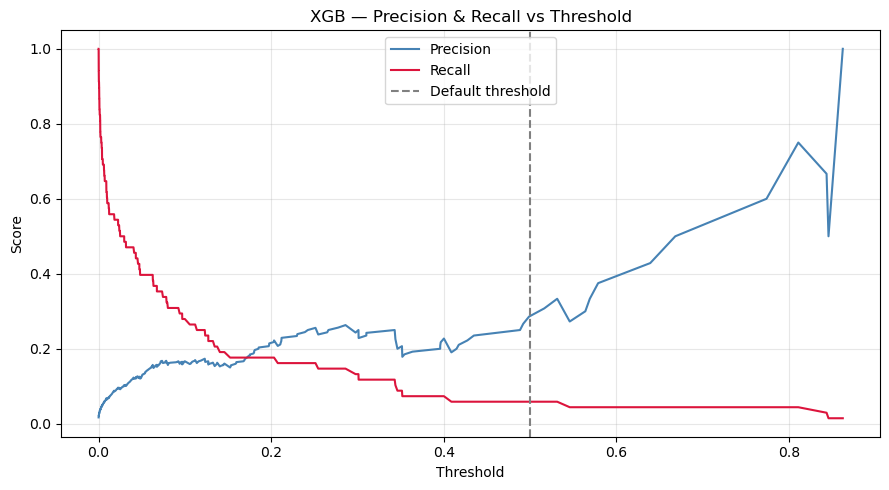

In [23]:
y_proba = xgb_balanced.predict_proba(X_test)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh, prec[:-1], label='Precision', color='steelblue')
ax.plot(thresh, rec[:-1], label='Recall', color='crimson')
ax.axvline(0.5, ls='--', color='gray', label='Default threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('XGB — Precision & Recall vs Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At threshold = 0.15:
  TN: 3864  FP: 68
  FN: 56  TP: 12
  Fraud caught: 12/68 (17.6%)
  False alarms: 68


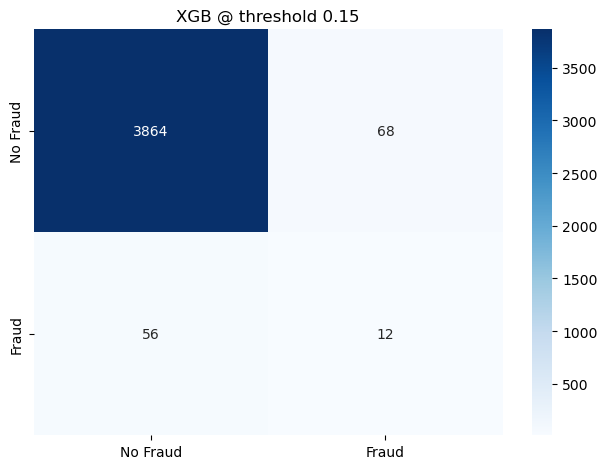

In [24]:
best_thresh = 0.15   # change based on your Cell 5 table
y_proba = xgb_balanced.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

print(f"At threshold = {best_thresh}:")
print(f"  TN: {tn}  FP: {fp}")
print(f"  FN: {fn}  TP: {tp}")
print(f"  Fraud caught: {tp}/68 ({tp/68*100:.1f}%)")
print(f"  False alarms: {fp}")

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.title(f'XGB @ threshold {best_thresh}')
plt.tight_layout()
plt.show()

In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

if not hasattr(SMOTE(), 'fit_resample'):
    pass  # install: pip install imbalanced-learn

smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        reg_lambda=1.0, eval_metric='aucpr',
        n_jobs=-1, random_state=42, tree_method='hist'
    ))
])
smote_pipeline.fit(X_train, y_train)

y_pred = smote_pipeline.predict(X_test)
y_proba = smote_pipeline.predict_proba(X_test)[:, 1]

print("XGB + SMOTE — TEST metrics:")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")

XGB + SMOTE — TEST metrics:
  Precision: 0.2500
  Recall:    0.0147
  F1:        0.0278
  PR-AUC:    0.1167


In [26]:
def metrics_at(model, X, y, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'F1':        f1_score(y, y_pred, zero_division=0),
        'PR-AUC':    average_precision_score(y, y_proba),
    }

final = pd.DataFrame({
    'LR baseline':          metrics_at(lr_pipeline, X_test, y_test),
    'LR balanced':          metrics_at(lr_balanced, X_test, y_test),
    'RF balanced':          metrics_at(rf_balanced, X_test, y_test),
    'XGB balanced (0.5)':   metrics_at(xgb_balanced, X_test, y_test),
    'XGB balanced (tuned)': metrics_at(xgb_balanced, X_test, y_test, threshold=best_thresh),
}).T.round(4)

final

,Precision,Recall,F1,PR-AUC
LR baseline,0.6667,0.0294,0.0563,0.2668
LR balanced,0.0570,0.6912,0.1053,0.2489
RF balanced,0.2500,0.1618,0.1964,0.1520
XGB balanced (0.5),0.3077,0.0588,0.0988,0.1410
XGB balanced (tuned),0.1500,0.1765,0.1622,0.1410


In [27]:
import json

joblib.dump(xgb_balanced, '../models/xgb_balanced.pkl')

# Also save the threshold so the API can use it at inference time
with open('../models/xgb_threshold.json', 'w') as f:
    json.dump({'threshold': best_thresh}, f)

print(f"Saved xgb_balanced.pkl with threshold {best_thresh}")

Saved xgb_balanced.pkl with threshold 0.15
